In [1]:
import thermomatch as match
match.ThermoImpexGenerator.create_local_database_if_not_existent = True

## _rdc_ is needed in the name of master-...csv file if the substance will be treated as a reaction but data is updated for substance - best is to provide the calculate reaction properties to begin with

[2025-12-28 11:43:47.883] [jsonio17] [info] Home directory is /home/dmiron


In [2]:
# Set path to `schemas` and `lua` not from the configuration file
match.ThermoImpexGenerator.setResourcesDirectory("../../Resources")

# Connect to Arango local database
generator = match.ThermoImpexGenerator("http://localhost:8529", "root", "", "ORD_TDB2020_v25_v2", True, match.ThermoImpexGenerator.File, True)

[jsonarango] [info] You are connected to: arango 3.9.12


In [3]:
generator.sourcedtbs = (["{\"26\" : \"PSI_NAGRA20\"}"]) 

## 1. Upload Database (if needed)

## 2. Delete reactions (duplicates and leave new ones), before reading new reactions in!!
## These are the reactions found in reacdc.new.csv files and were already in the TDB but the reaction was changed 

	AlOOH(cr) + 3H+ = Al3+ + 2H2O(l) 
    Fe(OH)3(mic) + 2H+ = Fe+3 + 2H2O(l)
	MgCO3(s) = Mg+2 + CO3-2
	Mg(OH)2(s) + H+ = Mg+2 + 2H2O(l)
    Si(OH)4(aq) 1 OH- -1 H2O(l) = SiO(OH)3-
    Si(OH)4(aq) 2 OH- -2 H2O(l) = SiO2(OH)2-2
	SiO2(am) + 4H2O(l) = Si(OH)4(aq)

## 3. Upload new records
## records found in files .new.csv are considered only

In [14]:
# Import data for new master solids, reacdc solids and aqueous

# Execute import from PSI table format data
description = [
    match.ImpexRowDescription("master-solids", "VertexSubstance", "records", "FormatTableFile", "scripts-in/master_substances.FormatTableFile.json"), # new solids # was master_substances_solids.FormatTableFile.json
    match.ImpexRowDescription("master-gases", "VertexSubstance", "records", "FormatTableFile", "scripts-in/master_substances.FormatTableFile.json"), # new solids
    match.ImpexRowDescription("master-aqueous", "VertexSubstance", "records", "FormatTableFile", "scripts-in/master_substances.FormatTableFile.json"), # new aqueous
    match.ImpexRowDescription("reacdc-solids", "VertexSubstance", "records", "FormatTableFile", "scripts-in/product_substances.FormatTableFile.json"), # new reactions solids 
    match.ImpexRowDescription("reacdc-aqueous", "VertexSubstance", "records", "FormatTableFile", "scripts-in/product_substances.FormatTableFile.json"), # new reactions aqueous 
    match.ImpexRowDescription("reacdc-solids", "VertexReaction", "records_and_links", "FormatTableFile", "scripts-in/product_reactions_dissolution.FormatTableFile.json"), # reaction records for dependent solid species and links to reactants
    match.ImpexRowDescription("reacdc-aqueous", "VertexReaction", "records_and_links", "FormatTableFile", "scripts-in/product_reactions.FormatTableFile.json"), # reaction records for dependent aqeuous species and links to reactants
    match.ImpexRowDescription("master-solids", "VertexPhase", "records_and_links", "FormatTableFile", "scripts-in/phase-solids.FormatTableFile.json"), # phase records and links to solid substance records
    match.ImpexRowDescription("reacdc-solids", "VertexPhase", "records_and_links", "FormatTableFile", "scripts-in/phase-solids.FormatTableFile.json"), # phase records and links to solid substance records
    # SIT
    match.ImpexRowDescription("SIT", "VertexPhase", "records", "FormatTableFile", "scripts-in/phase_sit.FormatTableFile.json"), # record for aq_sit phase
    match.ImpexRowDescription("SIT", "VertexMixingModel", "records", "FormatTableFile", "scripts-in/mixmod_sit.FormatTableFile.json"), # record for aq_sit mixing model
    match.ImpexRowDescription("SIT", "VertexInteraction", "records_and_links", "FormatTableFile", "scripts-in/int_Na.FormatTableFile.json"), # interaction records with Na+ and links to substance records
    match.ImpexRowDescription("SIT", "VertexInteraction", "records_and_links", "FormatTableFile", "scripts-in/int_Cl.FormatTableFile.json"), # interaction records with Cl- and links to substance records
    match.ImpexRowDescription("SIT", "VertexInteraction", "records_and_links", "FormatTableFile", "scripts-in/int_ClO4.FormatTableFile.json"), # interaction records with ClO4- and links to substance records
    match.ImpexRowDescription("ThermoDataSet", "VertexThermoDataSet", "records_and_links", "FormatTableFile", "scripts-in/thermodataset.FormatTableFile.json") # ThermoDataSet record and link to elements, substances, rdc
]

generator.runImport("TableImport", description, "data-in/temperature/master-solids.new.csv", "rdc_PSITDB2020");

[2025-12-28 13:14:24.017] [thermomatch] [info] Clear loaded data
[2025-12-28 13:14:24.017] [thermomatch] [info]  0% Preparing files ...
[2025-12-28 13:14:24.017] [thermomatch] [info]  10% Importing data ...
[2025-12-28 13:14:24.017] [thermomatch] [info]  10% Importing master-solids VertexSubstance ...
[2025-12-28 13:14:24.033] [thermomatch] [info]  40% Importing ThermoDataSet VertexThermoDataSet ...
[2025-12-28 13:14:24.034] [thermomatch] [info]  80% Load database to compare ...
[2025-12-28 13:14:24.035] [thermomatch] [info]  90% Generate Edges ...
[2025-12-28 13:14:24.035] [thermomatch] [info] Generate ThermoDataSet links
[jsonio17] [info] VertexThermoDataSet loading collection: 63, loading query: 2216
[2025-12-28 13:14:24.589] [thermomatch] [info]  100% Ready to test


In [5]:
# Import data for new master solids, reacdc solids and aqueous

# Execute import from PSI table format data
#description = [
#    match.ImpexRowDescription("master-solids", "VertexSubstance", "records", "FormatTableFile", "scripts-in/master_substances_solids.FormatTableFile.json"), # new solids
#    match.ImpexRowDescription("reacdc-solids", "VertexSubstance", "records", "FormatTableFile", "scripts-in/product_substances.FormatTableFile.json"), # new reactions solids 
#    match.ImpexRowDescription("reacdc-solids", "VertexReaction", "records_and_links", "FormatTableFile", "scripts-in/product_reactions_dissolution.FormatTableFile.json"), # reaction records for dependent solid species and links to reactants
#    match.ImpexRowDescription("master-solids", "VertexPhase", "records_and_links", "FormatTableFile", "scripts-in/phase-solids.FormatTableFile.json"), # phase records and links to solid substance records
#    match.ImpexRowDescription("reacdc-solids", "VertexPhase", "records_and_links", "FormatTableFile", "scripts-in/phase-solids.FormatTableFile.json"), # phase records and links to solid substance records
#    match.ImpexRowDescription("ThermoDataSet", "VertexThermoDataSet", "records_and_links", "FormatTableFile", "scripts-in/thermodataset.FormatTableFile.json") # ThermoDataSet record and link to elements, substances, rdc
#]

#generator.runImport("TableImport", description, "data-in/temperature/master-solids.new.csv", "rdc_PSITDB2020");

### update data of elements and reactions
### here the scripts also add the datasources of different properties

In [6]:
# updating data of elements with default oxidation states, molar masses, entropy and Cp from CODATA, NEA and SUCPRT
fields_list = [ "_id", "properties.symbol" ]
generator.updateFileToDatabase("FormatTableFile", "scripts-in/elements_update.FormatTableFile.json",
                    "../../datatypes/elements/data-in/elements.csv", "", "", fields_list )

# N_atm other and number 124

['elements/Ac;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Ag;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Al;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Am;0:ELEMENT;26:PSI_NAGRA20',
 'elements/As;0:ELEMENT;26:PSI_NAGRA20',
 'elements/B;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Ba;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Br;0:ELEMENT;26:PSI_NAGRA20',
 'elements/C;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Ca;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Cd;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Cf;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Cl;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Cm;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Cs;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Cu;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Eu;0:ELEMENT;26:PSI_NAGRA20',
 'elements/F;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Fe;0:ELEMENT;26:PSI_NAGRA20',
 'elements/H;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Hg;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Ho;0:ELEMENT;26:PSI_NAGRA20',
 'elements/I;0:ELEMENT;26:PSI_NAGRA20',
 'elements/K;0:ELEMENT;26:PSI_NAGRA20',
 'elements/Li;0:ELEMEN

In [8]:
# updating data of product reactions aqeuous with temperature dependency
fields_list = [ "_id", "properties.symbol", "properties.sourcetdb" ]

generator.updateFileToDatabase("FormatTableFile", "scripts-in/product_reactions_update.FormatTableFile.json",
                    "data-in/temperature/reacdc-aqueous.csv", "", "", fields_list )

['reactions/AlOH+2;26:PSI_NAGRA20;0',
 'reactions/Al(OH)2+;26:PSI_NAGRA20;0',
 'reactions/Al(OH)3(aq);26:PSI_NAGRA20;0',
 'reactions/Al(OH)4-;26:PSI_NAGRA20;0',
 'reactions/FeOH+;26:PSI_NAGRA20;0',
 'reactions/Fe(OH)2(aq);26:PSI_NAGRA20;0',
 'reactions/Fe(OH)3-;26:PSI_NAGRA20;0',
 'reactions/FeOH+2;26:PSI_NAGRA20;0',
 'reactions/Fe(OH)2+;26:PSI_NAGRA20;0',
 'reactions/Fe(OH)3(aq);26:PSI_NAGRA20;0',
 'reactions/Fe(OH)4-;26:PSI_NAGRA20;0',
 'reactions/SiO(OH)3-;26:PSI_NAGRA20;0',
 'reactions/SiO2(OH)2-2;26:PSI_NAGRA20;0',
 'reactions/CaSiO2(OH)2(aq);26:PSI_NAGRA20;0',
 'reactions/CO2(aq);26:PSI_NAGRA20;0',
 'reactions/NH4+;26:PSI_NAGRA20;0',
 'reactions/H2PO4-;26:PSI_NAGRA20;0',
 'reactions/H3PO4(aq);26:PSI_NAGRA20;0']

In [10]:
# updating data of product reactions solids with temperature dependency
fields_list = [ "_id", "properties.symbol", "properties.sourcetdb" ]

generator.updateFileToDatabase("FormatTableFile", "scripts-in/product_reactions_update.FormatTableFile.json",
                    "data-in/temperature/reacdc-solids.csv", "", "", fields_list )

['reactions/Fe(OH)3(mic);26:PSI_NAGRA20;0',
 'reactions/MgCO3(s);26:PSI_NAGRA20;0',
 'reactions/Mg(OH)2(s);26:PSI_NAGRA20;0_0',
 'reactions/CaSO4w2(cr);26:PSI_NAGRA20;0',
 'reactions/CaSO4w0.5(cr);26:PSI_NAGRA20;0',
 'reactions/SiO2(am);26:PSI_NAGRA20;0',
 'reactions/AlOOH(cr);26:PSI_NAGRA20;0',
 'reactions/Al(OH)3(s);26:PSI_NAGRA20;0',
 'reactions/AlOOH(alpha);26:PSI_NAGRA20;0',
 'reactions/Al(OH)3(mcr);26:PSI_NAGRA20;0',
 'reactions/AlOOH(mcr);26:PSI_NAGRA20;0']

## 2. calculate properties of reactions in RecordCalculator


### Dcomps

In [13]:
# updating data of master aqeuous species with temperature dependency based on HKF
fields_list = [ "_id", "properties.symbol", "properties.sourcetdb" ]

generator.updateFileToDatabase("FormatTableFile", "scripts-in/master_substances_update.FormatTableFile.json",
                    "data-in/temperature/master-aqueous.csv", "", "", fields_list )

[2025-12-28 12:52:13.418] [thermomatch] [info] ids = [ [ "substances/CaSiO2(OH)2(aq);2:SC_AQSOLUTE;26:PSI_NAGRA20", "_rdc_CaSiO2(OH)2(aq)", "defines/25464087" ], [ "substances/H2PO4-;2:SC_AQSOLUTE;26:PSI_NAGRA20", "_rdc_H2PO4-", "defines/25393186" ], [ "substances/H3PO4(aq);2:SC_AQSOLUTE;26:PSI_NAGRA20", "_rdc_H3PO4(aq)", "defines/25393210" ] ]


['substances/e-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/H2O(l);3:SC_AQSOLVENT;26:PSI_NAGRA20',
 'substances/Cl-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Na+;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/K+;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Ca+2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Mg+2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Fe+2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Fe+3;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Al+3;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/OH-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/F-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/ClO4-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/NO3-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/HS-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/HCO3-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/CO3-2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/SO4-2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/HPO4-2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/PO4-3;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Si(OH)4

## 3. calculate properties of reaction dependent components from their reaction and reactants in RecordCalculator (max 200 at a time)
## sort by name and select only _ rdc _

### Dcomps
### This will overwrite any properties calculated above

In [15]:
# updating data of master solids species with temperature dependency based on Cp coeff
fields_list = [ "_id", "properties.symbol", "properties.sourcetdb" ]

generator.updateFileToDatabase("FormatTableFile", "scripts-in/master_substances_solids_gases_update.FormatTableFile.json",
                    "data-in/temperature/master-solids.csv", "", "", fields_list )

[2025-12-30 10:10:04.043] [thermomatch] [info] ids = [ [ "substances/Al(OH)3(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "Gibbsite", "defines/25399052" ], [ "substances/Al(OH)3(s);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Bayerite", "defines/25594263" ], [ "substances/Fe2O3(alpha);0:SC_COMPONENT;26:PSI_NAGRA20", "Hematite", "defines/25421483" ], [ "substances/Fe3O4(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "Magnetite", "defines/25421473" ], [ "substances/FeOOH(alpha);0:SC_COMPONENT;26:PSI_NAGRA20", "Goethite", "defines/25421503" ], [ "substances/FeOOH(gamma);0:SC_COMPONENT;26:PSI_NAGRA20", "Lepidocrocite", "defines/25421513" ], [ "substances/Fe(OH)3(mic);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ferrihydrite-2line", "defines/25594209" ], [ "substances/Ca(OH)2(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "Portlandite", "defines/25398940" ], [ "substances/Mg(OH)2(s);0:SC_COMPONENT;26:PSI_NAGRA20", "Brucite", "defines/25594227" ], [ "substances/CaCO3(calcite);0:SC_COMPONENT;26:PSI_NAGRA20", "Calcite", "defines/25398956

['substances/SiO2(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Al2O3(alpha);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Al(OH)3(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Al(OH)3(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Fe2O3(alpha);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Fe3O4(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/FeOOH(alpha);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/FeOOH(gamma);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Fe(OH)3(mic);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ca(OH)2(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Mg(OH)2(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/CaCO3(calcite);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/CaMg(CO3)2(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/MgCO3(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/CaSO4w2(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/CaSO4(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/CaSiO3(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/AlOOH(cr);0:SC_COMPO

:PSI_NAGRA20


In [16]:
# updating data of master gases species with temperature dependency based on Cp coeff
fields_list = [ "_id", "properties.symbol", "properties.sourcetdb" ]

generator.updateFileToDatabase("FormatTableFile", "scripts-in/master_substances_solids_gases_update.FormatTableFile.json",
                    "data-in/temperature/master-gases.csv", "", "", fields_list )

[2025-12-30 10:19:44.050] [thermomatch] [info] ids = [ [ "substances/CH4(g);1:SC_GASFLUID;26:PSI_NAGRA20", "CH4(g)", "defines/25393460" ], [ "substances/CO2(g);1:SC_GASFLUID;26:PSI_NAGRA20", "CO2(g)", "defines/25393470" ], [ "substances/H2(g);1:SC_GASFLUID;26:PSI_NAGRA20", "H2(g)", "defines/25393476" ], [ "substances/H2S(g);1:SC_GASFLUID;26:PSI_NAGRA20", "H2S(g)", "defines/25393496" ], [ "substances/H2Se(g);1:SC_GASFLUID;26:PSI_NAGRA20", "H2Se(g)", "defines/25406363" ], [ "substances/N2(g);1:SC_GASFLUID;26:PSI_NAGRA20", "N2(g)", "defines/25393482" ], [ "substances/O2(g);1:SC_GASFLUID;26:PSI_NAGRA20", "O2(g)", "defines/25393488" ] ]
[2025-12-30 10:19:44.050] [thermomatch] [info] Removed defines from substance id substances/CH4(g);1:SC_GASFLUID;26:PSI_NAGRA20


['substances/CH4(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/CO2(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/H2(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/H2S(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/H2Se(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/Hg(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/N2(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/O2(g);1:SC_GASFLUID;26:PSI_NAGRA20',
 'substances/H2O(g);1:SC_GASFLUID;26:PSI_NAGRA20']

[2025-12-30 10:19:44.050] [thermomatch] [info] Removed defines from substance id substances/CO2(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-12-30 10:19:44.051] [thermomatch] [info] Removed defines from substance id substances/H2(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-12-30 10:19:44.051] [thermomatch] [info] Removed defines from substance id substances/H2S(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-12-30 10:19:44.052] [thermomatch] [info] Removed defines from substance id substances/H2Se(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-12-30 10:19:44.052] [thermomatch] [info] Removed defines from substance id substances/N2(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-12-30 10:19:44.053] [thermomatch] [info] Removed defines from substance id substances/O2(g);1:SC_GASFLUID;26:PSI_NAGRA20


In [17]:
# Updating data for molar volumes of solids
# !!! see the script as it overwrites the first reference 
fields_list = [ "_id", "properties.symbol", "properties.sourcetdb" ]

generator.updateFileToDatabase("FormatTableFile", "scripts-in/master_substances_solids_update_volume.FormatTableFile.json",
                    "data-in/temperature/master-solids-volume.csv", "", "", fields_list )

[2025-12-30 10:21:02.287] [thermomatch] [info] ids = [ [ "substances/Ac(OH)3(ag);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ac(OH)3(aged)", "defines/25404787" ], [ "substances/Ac(OH)3(fr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ac(OH)3(fresh)", "defines/25404777" ], [ "substances/Ac2(Oxa)3(s);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ac2(Oxa)3(s)", "defines/25404793" ], [ "substances/Ag2CO3(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag2CO3(cr)", "defines/25408688" ], [ "substances/Ag2O(am);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag2O(am)", "defines/25408646" ], [ "substances/Ag2O(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag2O(cr)", "defines/25408656" ], [ "substances/Ag2S(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag2S(cr)", "defines/25408716" ], [ "substances/Ag2SeO3(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag2SeO3(cr)", "defines/25408732" ], [ "substances/Ag2SeO4(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag2SeO4(cr)", "defines/25408724" ], [ "substances/Ag2SO4(s);0:SC_COMPONENT;26:PSI_NAGRA20", "_

['substances/Ac(OH)3(ag);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ac(OH)3(fr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ac2(Oxa)3(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2CO3(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2O(am);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2O(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2S(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2Se(alpha);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2SeO3(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2SeO4(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag2SO4(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/Ag3PO4(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/AgBr(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/AgCl(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/AgCN(s);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/AgI(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'substances/AgSeCN(cr);0:SC_COMPONENT;26:PSI_NAGRA20',
 'subs

rdc_Ag2SO4(s)", "defines/25408706" ], [ "substances/Ag3PO4(s);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Ag3PO4(s)", "defines/25408698" ], [ "substances/AgBr(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_AgBr(cr)", "defines/25408672" ], [ "substances/AgCl(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_AgCl(cr)", "defines/25408664" ], [ "substances/AgCN(s);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_AgCN(s)", "defines/25408740" ], [ "substances/AgI(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_AgI(cr)", "defines/25408680" ], [ "substances/AgSeCN(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_AgSeCN(cr)", "defines/25408754" ], [ "substances/Al2Si2O5(OH)4(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Kaolinite", "defines/25464281" ], [ "substances/AlOOH(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Boehmite", "defines/25594253" ], [ "substances/Am(OH)3(am);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Am(OH)3(am)", "defines/25411166" ], [ "substances/Am(OH)3(cr);0:SC_COMPONENT;26:PSI_NAGRA20", "_rdc_Am(OH)3(cr)", "defines/25411156" 

## 4. Calculate DComp props with G0 null

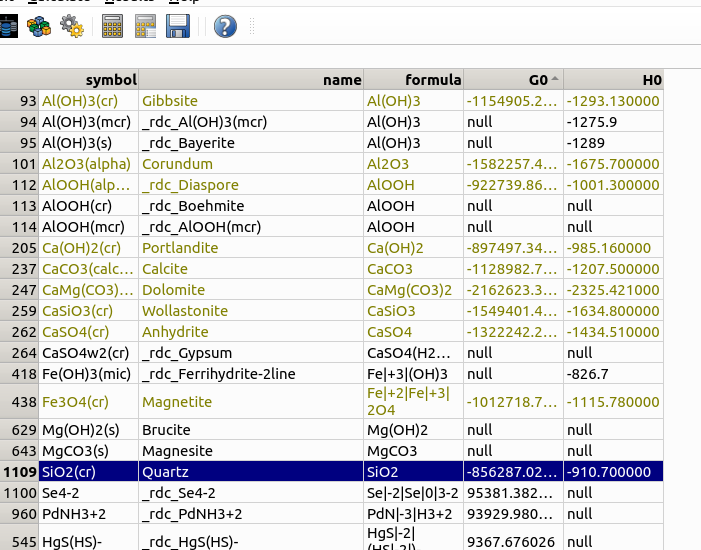

sort data wiht G0 null. Calculate properties from dependent reaction for records with _rdc_. Finally, calculate substance properties for the remaining records.

Hematite, goethite and lepidocrocite  calculate subst props for entahlpy 


added entropy of reaction for Al(OH)3(mic) and Fe(OH)3(mic) so that all data are there. 
added properties to MgCO3(cr) and Mg(OH)2(cr) enthalpy so all properties are there when calculating the properties


remove old reactions

['substances/e-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/H2O(l);3:SC_AQSOLVENT;26:PSI_NAGRA20',
 'substances/Cl-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Na+;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/K+;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Ca+2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Mg+2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Fe+2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Fe+3;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Al+3;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/OH-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/F-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/ClO4-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/NO3-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/HS-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/HCO3-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/CO3-2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/SO4-2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/HPO4-2;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/PO4-3;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/Si(OH)4(aq);2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/NO2-;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/NH4+;2:SC_AQSOLUTE;26:PSI_NAGRA20',
 'substances/CaSiO2(OH)2(aq);2:SC_AQSOLUTE;26:PSI_NAGRA20']

[2025-08-06 11:53:13.561] [thermomatch] [info] Removed defines from substance id substances/Al(OH)3(cr);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.568] [thermomatch] [info] Removed defines from substance id substances/Fe2O3(alpha);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.568] [thermomatch] [info] Removed defines from substance id substances/Fe3O4(cr);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.568] [thermomatch] [info] Removed defines from substance id substances/FeOOH(alpha);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.568] [thermomatch] [info] Removed defines from substance id substances/FeOOH(gamma);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.569] [thermomatch] [info] Removed defines from substance id substances/Ca(OH)2(cr);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.569] [thermomatch] [info] Removed defines from substance id substances/Mg(OH)2(s);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.569] [thermomatch] [info] Removed defines from substance id substances/CaCO3(calcite);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.569] [thermomatch] [info] Removed defines from substance id substances/MgCO3(s);0:SC_COMPONENT;26:PSI_NAGRA20
[2025-08-06 11:53:13.569] [thermomatch] [info] Removed defines from substance id substances/CaSO4(cr);0:SC_COMPONENT;26:PSI_NAGRA20

[2025-08-06 11:53:46.936] [thermomatch] [info] Removed defines from substance id substances/CO2(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-08-06 11:53:46.937] [thermomatch] [info] Removed defines from substance id substances/H2(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-08-06 11:53:46.937] [thermomatch] [info] Removed defines from substance id substances/H2S(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-08-06 11:53:46.938] [thermomatch] [info] Removed defines from substance id substances/H2Se(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-08-06 11:53:46.938] [thermomatch] [info] Removed defines from substance id substances/N2(g);1:SC_GASFLUID;26:PSI_NAGRA20
[2025-08-06 11:53:46.938] [thermomatch] [info] Removed defines from substance id substances/O2(g);1:SC_GASFLUID;26:PSI_NAGRA20

CH4(g)
CO2(g)
CO3-2
Ca(OH)2(cr)
CaCO3(calcite)
CaSO4(cr)

Fe2O3(alpha)
Fe3O4(cr)
FeOOH(alpha)
FeOOH(gamma)

H2(g)
H2S(g)
H2Se(g)
HS-

Mg(OH)2(s)
MgCO3(s)

N2
O2
OH-

## 5. Export to GEMS3 backup format (using thermomatch gui) 

# Fixes needed in GEMS


Set water model HWF in GEMS

Problems with too long formulas of clays